In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt

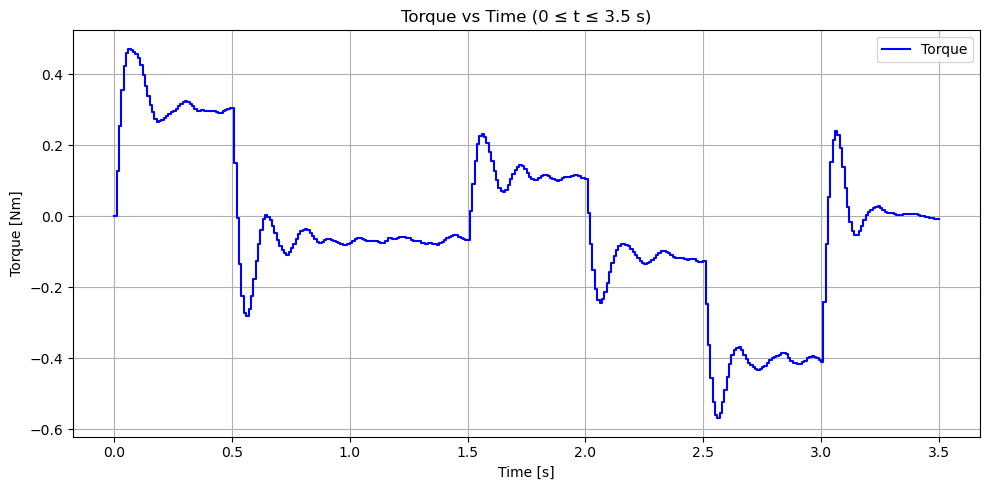

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Datei einlesen
df = pd.read_csv('simdata_torque.txt')

# Daten auf den Bereich 0 ≤ t ≤ 3.5 beschränken
df_filtered = df[df['Time'] <= 3.5]

# Plot erstellen
plt.figure(figsize=(10, 5))
plt.step(df_filtered['Time'], df_filtered['Torque'], where='post', label='Torque', color='blue')
plt.title('Torque vs Time (0 ≤ t ≤ 3.5 s)')
plt.xlabel('Time [s]')
plt.ylabel('Torque [Nm]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


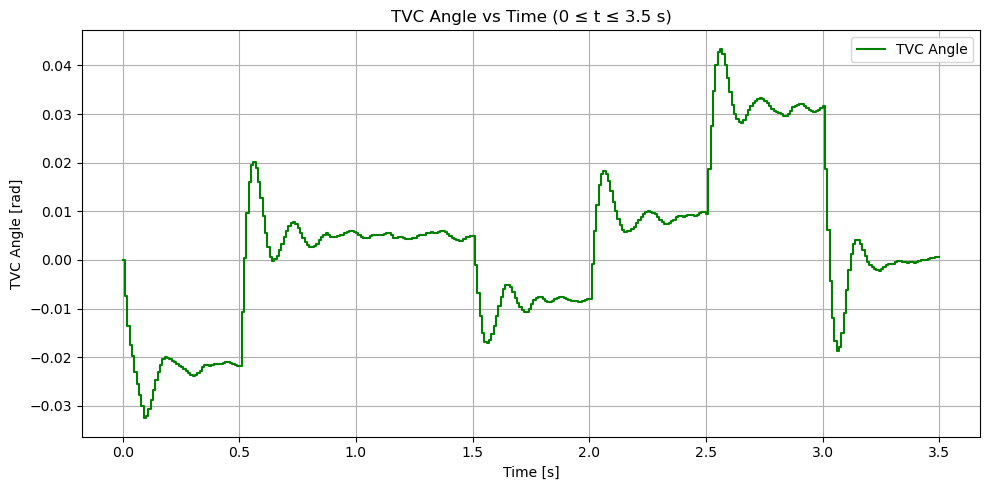

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Datei einlesen
df_tvc = pd.read_csv('simdata_tvc.txt')

# Daten auf 0 ≤ t ≤ 3.5 beschränken
df_tvc_filtered = df_tvc[df_tvc['Time'] <= 3.5]

# Plot als Treppenfunktion
plt.figure(figsize=(10, 5))
plt.step(df_tvc_filtered['Time'], -df_tvc_filtered['TVC_Angle'], where='post', label='TVC Angle', color='green')
plt.title('TVC Angle vs Time (0 ≤ t ≤ 3.5 s)')
plt.xlabel('Time [s]')
plt.ylabel('TVC Angle [rad]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


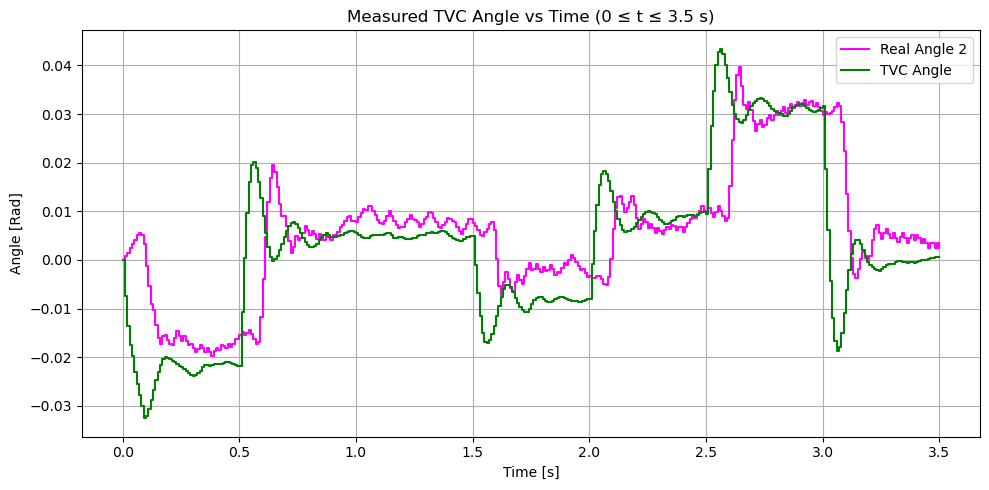

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Datei einlesen
df_real1 = pd.read_csv('simdata_realtvc.txt')

# Daten auf den Bereich 0 ≤ t ≤ 3.5 beschränken
df_filtered_real1 = df_real1[df_real1['Time'] <= 3.5]

# Datei einlesen
df_real2 = pd.read_csv('simdata_realtvc2.txt')

# Daten auf 0 ≤ t ≤ 3.5 beschränken
df_filtered_real2 = df_real2[df_real2['Time'] <= 3.5]

# Datei einlesen
df_tvc = pd.read_csv('simdata_tvc.txt')

# Daten auf 0 ≤ t ≤ 3.5 beschränken
df_tvc_filtered = df_tvc[df_tvc['Time'] <= 3.5]



# Plot erstellen
plt.figure(figsize=(10, 5))
plt.step(df_filtered_real2['Time'], -(df_filtered_real2['Real_Angle']-0.0701), where='post', label='Real Angle 2', color='magenta')
plt.step(df_tvc_filtered['Time'], -df_tvc_filtered['TVC_Angle'], where='post', label='TVC Angle', color='green')
plt.title('Measured TVC Angle vs Time (0 ≤ t ≤ 3.5 s)')
plt.xlabel('Time [s]')
plt.ylabel('Angle [Rad]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Get numpy arrays
u = df_tvc_filtered['TVC_Angle'].values
y = df_filtered['Real_Angle'].values
t = df_filtered['Time'].values
Ts = t[1] - t[0]  # Sampling time

# Cross-correlation
corr = np.correlate(y - np.mean(y), u - np.mean(u), mode='full')
lags = np.arange(-len(u) + 1, len(u))
lag_at_max = lags[np.argmax(corr)]
delay_time = lag_at_max * Ts

print(f"Estimated delay: {delay_time:.5f} seconds")


Estimated delay: 0.09000 seconds
0.01


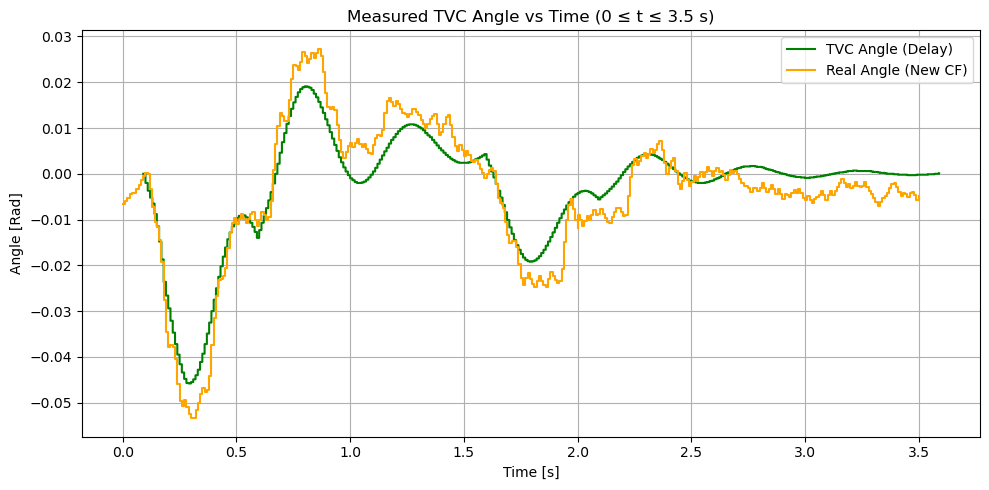

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Datei einlesen
df_tvc_delay = pd.read_csv('simdata_tvc_delay.txt')

# Daten auf den Bereich 0 ≤ t ≤ 3.5 beschränken
df_tvc_delay = df_tvc_delay[df_tvc_delay['Time'] <= 3.5]

## Datei einlesen
df_realtvc_delay = pd.read_csv('simdata_realtvc_delay.txt')

# Daten auf den Bereich 0 ≤ t ≤ 3.5 beschränken
df_realtvc_delay = df_realtvc_delay[df_realtvc_delay['Time'] <= 3.5]

## Datei einlesen
df_realtvc_delayc = pd.read_csv('simdata_realtvc_delayc.txt')

# Daten auf den Bereich 0 ≤ t ≤ 3.5 beschränken
df_realtvc_delayc = df_realtvc_delayc[df_realtvc_delayc['Time'] <= 3.5]

# Plot erstellen
plt.figure(figsize=(10, 5))
plt.step(df_tvc_delay['Time']+0.09, -df_tvc_delay['TVC_Angle'], where='post', label='TVC Angle (Delay)', color='green')
#plt.step(df_realtvc_delay['Time'], -(df_realtvc_delay['Real_Angle']-0.0619), where='post', label='Real Angle (Delay)', color='magenta')
plt.step(df_realtvc_delayc['Time'], -(df_realtvc_delayc['Real_Angle']-0.0691), where='post', label='Real Angle (New CF)', color='orange')
plt.title('Measured TVC Angle vs Time (0 ≤ t ≤ 3.5 s)')
plt.xlabel('Time [s]')
plt.ylabel('Angle [Rad]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()